<a href="https://colab.research.google.com/github/hclperera/Cat-Breed-Identification/blob/main/Implementation1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
from google.colab import drive, files
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Mount Google Drive
drive.mount('/content/drive')

# Extract dataset from ZIP
drive_path = '/content/drive/MyDrive/Project/cats.zip'
extract_path = '/content/dataset'

if os.path.exists(drive_path):
    with zipfile.ZipFile(drive_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully to /content/dataset")
else:
    print("Error: ZIP file not found in Drive. Check the file name.")

Mounted at /content/drive
Dataset extracted successfully to /content/dataset


In [2]:
# Constants
BATCH_SIZE = 32
IMG_SIZE = (180, 180)
# Update this if your folder structure is /content/dataset/cat breeds/
data_dir = '/content/dataset/cat breeds'

# Load Training Dataset (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load Validation Dataset (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Target Breeds: {class_names}") # Calico, Persian, Bombay, Siamese

Found 7813 files belonging to 4 classes.
Using 6251 files for training.
Found 7813 files belonging to 4 classes.
Using 1562 files for validation.
Target Breeds: ['Bombay', 'Calico', 'Persian', 'Siamese']


In [3]:
num_classes = len(class_names)

model = models.Sequential([
    # Input Rescaling (Normalization to [0, 1])
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),

    # First Convolutional Block
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes) # Logic handled by loss function
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,023,748 (30.61 MB)

 Trainable params: 8,023,748 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.3923 - loss: 1.4036 - val_accuracy: 0.5109 - val_loss: 1.0306
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - accuracy: 0.5576 - loss: 0.9824 - val_accuracy: 0.5391 - val_loss: 1.0320
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.6121 - loss: 0.8810 - val_accuracy: 0.5800 - val_loss: 1.0252
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.6878 - loss: 0.7301 - val_accuracy: 0.5627 - val_loss: 1.1575
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.7816 - loss: 0.5408 - val_accuracy: 0.5384 - val_loss: 1.5098
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.8504 - loss: 0.3743 - val_accuracy: 0.5634 - val_loss: 1.7591
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.8977 - loss: 0.2700 - val_accuracy: 0.5397 - val_loss: 2.1109
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.9402 - loss: 0.1718 - 

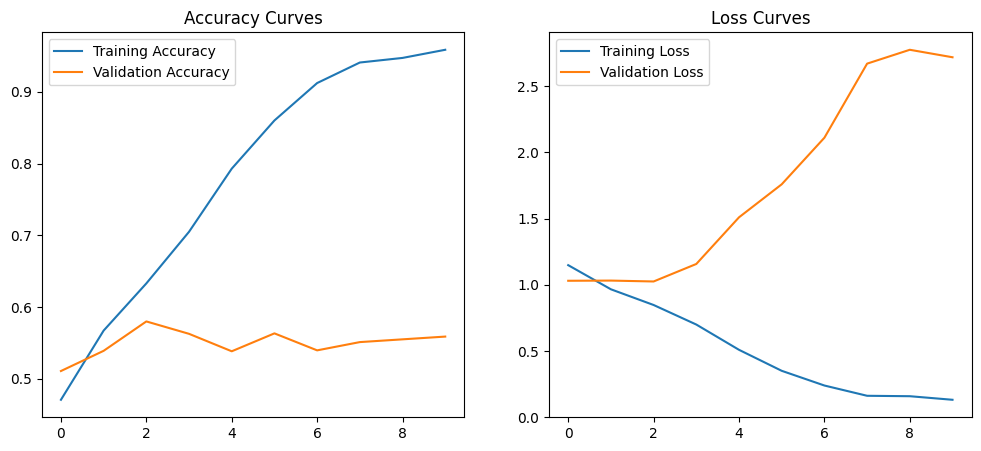

In [4]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

# Visualizing Performance
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

In [6]:
# Save the model to Drive
model_save_path = '/content/drive/MyDrive/Project/model_v1.h5'
model.save(model_save_path)
print(f"Model saved successfully to: {model_save_path}")



Model saved successfully to: /content/drive/MyDrive/Project/model_v1.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 899ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/

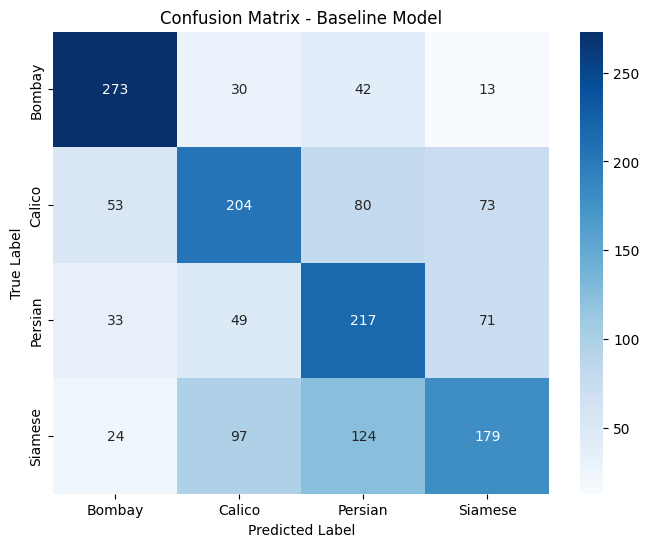

In [13]:
# 1. Get all true labels and predictions from the validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Baseline Model')
plt.show()

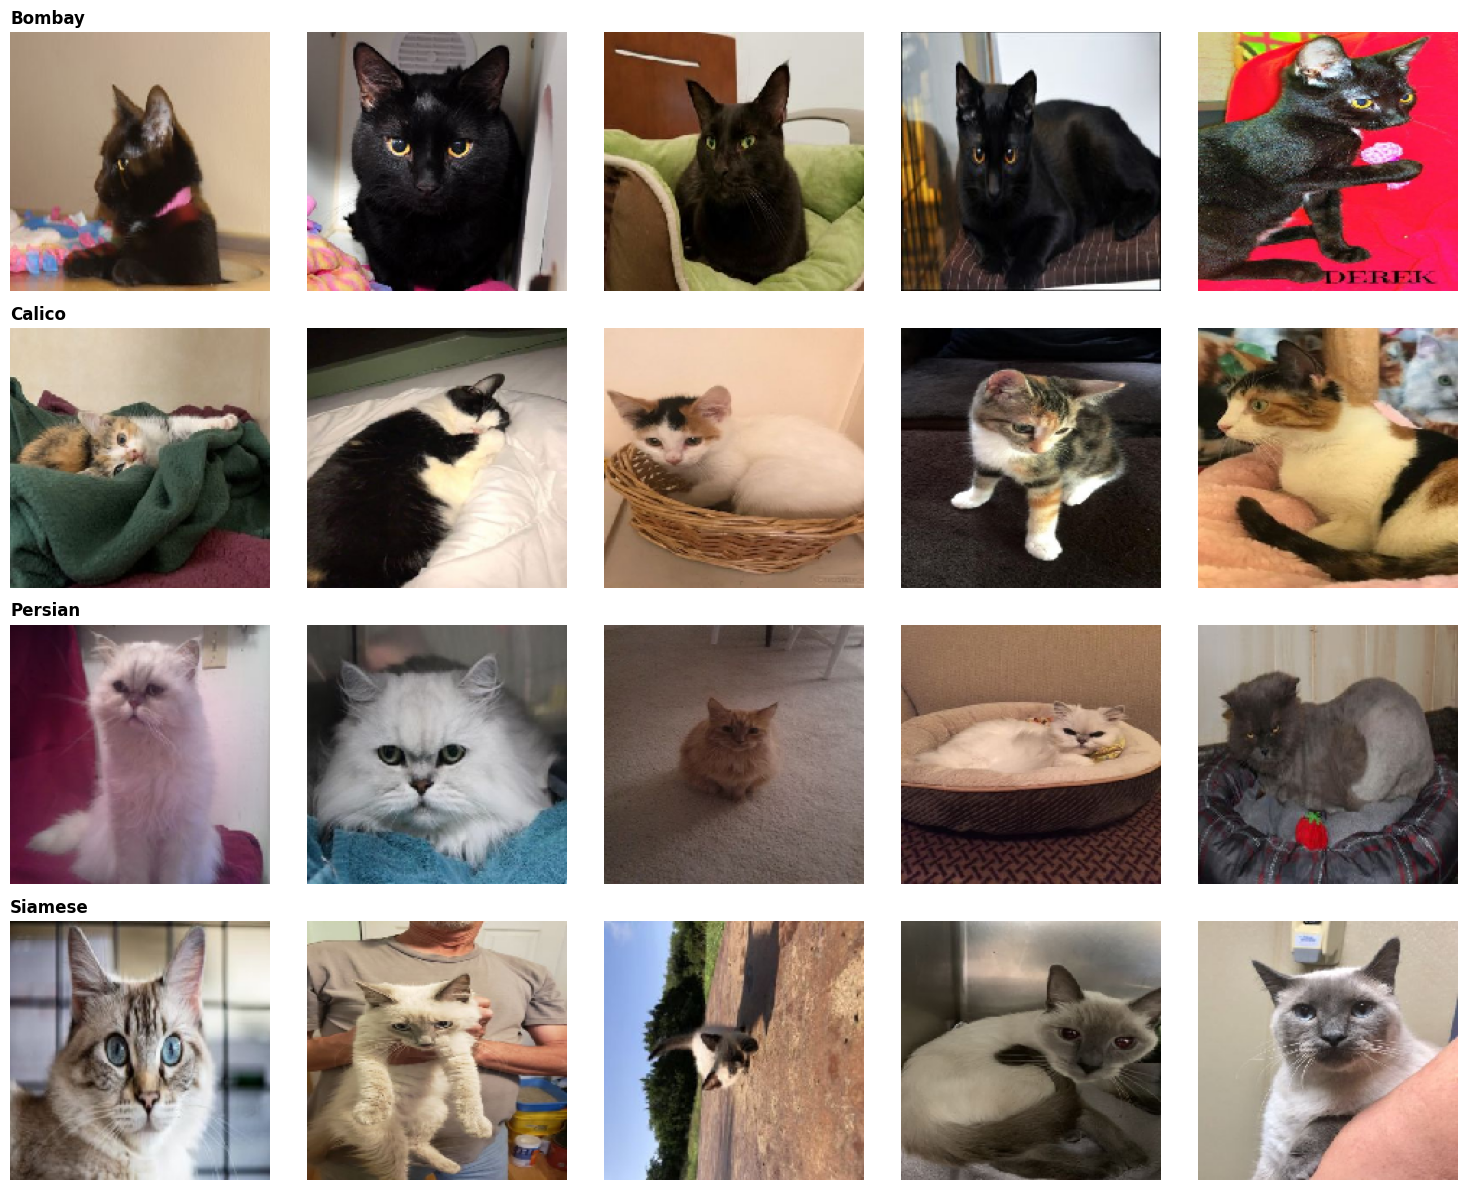

In [12]:
import matplotlib.pyplot as plt
import os
import tensorflow as tf

# Define the path to your extracted dataset
data_dir = '/content/dataset/cat breeds'

# Get the list of class names (Calico, Persian, Bombay, Siamese)
class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

# Set up the plot (4 rows for classes, 5 columns for images)
fig, axes = plt.subplots(len(class_names), 5, figsize=(15, 12))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)
    # Get first 5 image files from the folder
    img_list = os.listdir(class_path)[:5]

    for j, img_name in enumerate(img_list):
        img_path = os.path.join(class_path, img_name)
        img = tf.keras.utils.load_img(img_path, target_size=(180, 180))

        # Plot image in the grid
        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        # Only label the first image in each row for a cleaner look
        if j == 0:
            axes[i, j].set_title(class_name, loc='left', fontweight='bold')

plt.tight_layout()
plt.show()

Upload a cat image to test:


Saving download.jpg to download.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


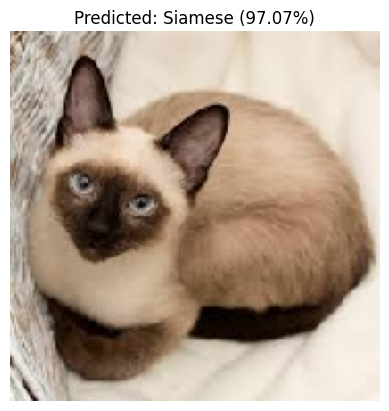

In [10]:
# Manual Test
print("Upload a cat image to test:")
uploaded = files.upload()

for fn in uploaded.keys():
    img = image.load_img(fn, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    plt.imshow(img)
    plt.title(f"Predicted: {class_names[np.argmax(score)]} ({100 * np.max(score):.2f}%)")
    plt.axis('off')
    plt.show()